Will be implementing a few classes her

First one will be LQR solver with Riccati:
    Inputs for constructor:
        xhist, mu_distr, restrictions (using barrier)



In [13]:
import numpy as np
import autograd.numpy as anp
from autograd import grad, jacobian, hessian

In [30]:
class iLQR:
    def __init__(self, R, A, B, mu_distr, h, states_num, control_num, Tfinal, x0, v0):
        print("Init")
        self.R = R
        self.A = A
        self.B = B
        self.mu_distr = mu_distr
        self.h = h 
        self.states_num = states_num
        self.control_num = control_num
        self.N = int(Tfinal / h) + 1
        self.Q = np.zeros((states_num, states_num, self.N))
        self.QN = np.diag([5000.0, 5000.0, 500.0, 500.0])
        self.target = np.zeros((states_num, 1)).flatten()
        
        
        # Constrains
        self.Eq = np.zeros((states_num, self.N))
        self.Ineq = np.zeros((states_num, self.N))
        self.EqMat = np.zeros((states_num , states_num, self.N))
        self.IneqMat = np.zeros((states_num , states_num, self.N))
        self.lm = np.zeros(( states_num, self.N))
        self.m = np.zeros(( states_num, self.N))
        
        self.p = 0.1
        # Violation increase
        self.phi = 1.1
        
        # Setting initial coordinates
        self.xhist = np.ones((states_num, self.N))
        self.xhist[0, :] = x0
        self.xhist[1, :] = v0
        
        self.uhist = np.zeros((control_num, self.N))
        print("Uhist initialized as ", self.uhist.shape)
        
        # Forward pass variables
        self.P = np.zeros((states_num, states_num, self.N))
        self.pp = np.zeros((states_num, self.N))
        self.K = np.zeros((control_num, states_num, self.N - 1))
        self.d = np.zeros((control_num, self.N - 1))
        
        # Utility
        self.Last_error = 0
        self.Equality_error = 0
        self.Inequality_error = 0
        self.Obstacle_error = 0 # Currently not used
        self.history = []
        
        # Setting constraint x equal to 2
        #self.EqMat[0,0 , :] = 1
        #self.EqMat[1,1 , :] = 1
        #self.Eq[0,:] = 8
        #self.Eq[1,:] = 3
        
        # Obstacle avoidance
        
        self.space_states = 2
        self.MAX_OBST = 3
        self.yu = 0 # Between 0 and 1, controls how careful we are
        self.obst_x = np.zeros((self.space_states, self.MAX_OBST))
        self.obst_r = np.zeros((1, self.MAX_OBST))
        self.obst_lm = np.zeros((self.MAX_OBST, self.N))
        self.obst_scalar = 100
        
        # Add obstaclat at 5,5 radius 1
        self.obst_x[:, 0] = np.array([[5], [5]]).flatten()
        self.obst_r[:, 0] = np.array(1)
        
        # Add obstaclat at 4,2 radius 1
        self.obst_x[:, 1] = np.array([[8], [8]]).flatten()
        self.obst_r[:, 1] = np.array(1)
        
        
        self.obst_x[:, 2] = np.array([[2], [3]]).flatten()
        self.obst_r[:, 2] = np.array(1)
        
    def constrains_error(self, x_):
        x_ = x_.flatten()
        diff = x_[0 : self.space_states, None] - self.obst_x
        vio = self.obst_r**2 - anp.sum(diff ** 2, axis=0)
        vio_buff = ( (self.obst_r**2 + 3) - anp.sum(diff ** 2, axis=0) )
        return vio * self.obst_scalar + anp.maximum(0, vio_buff) * 0.1
        # Not callable.
        # Called by L to add total constrains
        
    def obst_I(self,x_, obst_lm):
        vio = self.constrains_error(x_).flatten()
        lm = obst_lm.flatten()
        obst_I_mat = np.identity(self.MAX_OBST) * 0
        for i in range(self.MAX_OBST):
            if vio[i] > 0 or lm[i] > 0:
                obst_I_mat[i , i] = 1.0
        return obst_I_mat
        
    def backward_pass(self):
        print("Backward pass in the area")
        
        Error = 0
        
        # Cleaning
        self.P *= 0
        self.K *= 0
        self.pp *= 0
        
        # Linearize dynamics
        # In my case, linear so no need
        
        x = self.xhist[:, self.N - 1]
        u = np.zeros((self.control_num))
        
        # Computing last state Q
        k = self.N - 1
        L_fixed = lambda x_arg: self.L(x_arg, u, self.lm[:, k], self.p, self.EqMat[:, :, k], self.Eq[:, k], self.obst_lm[:, k])
        H = hessian(L_fixed)(x)
        print("H obstacle part eigenvalues:", np.linalg.eigvals(H))
        G = grad(L_fixed)(x)
        self.Q[:, :, k] = H
        self.P[:, :, k] = self.Q[:, :, k]
        self.pp[:, k] =  G
        
        # KP calculations
        for i in range(self.N - 2, -1, -1):
            # Computing Q for previous
            x = self.xhist[:, i]
            u = self.uhist[:, i]
            L_fixed = lambda x_arg: self.L(x_arg, u, self.lm[:, i], self.p, self.EqMat[:, :, i], self.Eq[:, i], self.obst_lm[:, i])
            H = hessian(L_fixed)(x)
            # Reconstruct H to be positive definite
            evals, evecs = np.linalg.eigh(H)
            # Flip the negative signs or set them to a small positive floor
            evals = np.maximum(evals, 1e-4) 
            H = evecs @ np.diag(evals) @ evecs.T
            self.Q[:, :, i] = H

            q = self.Q[:, :, i] @ self.xhist[:, i]
            r = self.R @ self.uhist[:, i]
            
            # Derivatives of Q (S) respect to x and u
            L_fixed_x = lambda x_arg: self.L(x_arg, u, self.lm[:, i], self.p, self.EqMat[:, :, i], self.Eq[:, i], self.obst_lm[:, i])
            L_fixed_u = lambda u_arg: self.L(x, u_arg, self.lm[:, i], self.p, self.EqMat[:, :, i], self.Eq[:, i], self.obst_lm[:, i])

            lx = grad(L_fixed_x)(x)
            lu = grad(L_fixed_u)(u)

            gx = lx + self.A.T @ self.pp[:, i + 1]
            gu = lu + self.B.T @ self.pp[:, i + 1]
            
            #iLQR Gauss Newton (ignoring 2 order terms)
            Gxx = self.Q[:, :, i] + self.A.T @ self.P[:, :, i + 1] @ self.A
            Guu = ( self.R + self.B.T @ self.P[:, :, i + 1] @ self.B )
            Gxu = self.A.T @ self.P[:, :, i + 1] @ self.B
            Gux = self.B.T @ self.P[:, :, i + 1] @ self.A
            
            # Regularizing Guu cuz we are taking its inverse
            beta = 1e-6
            Guu = Guu + beta * np.eye(self.control_num)
            
            # Computing important thing
            self.d[:, i] = np.linalg.solve(Guu, gu)
            self.K[:, :, i] = np.linalg.solve(Guu, Gux) 
            
            self.pp[:, i] = gx - self.K[:, :, i].T @ gu + self.K[:, :, i].T @ Guu @ self.d[:,i] - Gxu @ self.d[:,i]
            self.P[:, :, i] = Gxx + self.K[:, :, i].T @ Guu @ self.K[:, :, i] - Gxu @ self.K[:, :, i] - self.K[:, :, i].T @ Gux
        
            Error += gu.T * self.d[:, i]
        
        return Error
    
    def reset_target(self):
        self.target = np.zeros((self.states_num, 1)).flatten()
    
    def set_target(self, target):
        self.target = target.flatten()
        print("Target set", self.target.shape)
    
    def L(self, x, u, lm, p, EqMat, Eq, obst_lm):
        # Cost to be minimized
        # Will replace i with full matrix mult later
        x = x.flatten()
        u = u.flatten()
        Q_matrix = np.identity(self.states_num)
        basic_err = (x - self.target).T @ Q_matrix @ (x - self.target) + u.T @ u
        
        #Equality
        
        try:
            EqDiff = (EqMat @ x - Eq.flatten())
            EqErr = lm.T @ EqDiff + p/2 * EqDiff.T @ EqDiff
            self.Equality_error = EqErr
        except:
            print("Equality terms mismatch")
        
        #Inequality
        
        
        cbf_violation = self.constrains_error(x).flatten()
        lm_flat = obst_lm.flatten()

        I_mat = self.obst_I(x, obst_lm)

        linear_term = anp.dot(lm_flat, cbf_violation)

        # We use the I_mat to zero out non-active violations
        quad_term = (p / 2.0) * (cbf_violation.T @ I_mat @ cbf_violation)

        cbf_cost = linear_term + quad_term
        
        # Final error
        try:
            self.Last_error = basic_err + EqErr + cbf_cost 
            return basic_err + EqErr + cbf_cost
        except:
            print("Error shaped didn't match")
            print(basic_err.shape, u.T.shape, self.R.shape, u.shape)
    
    def report(self, xhist_=None, uhist_=None, silent=False):
        if xhist_ is None: xhist_ = self.xhist
        if uhist_ is None: uhist_ = self.uhist

        Q_matrix = np.identity(self.states_num)
        total_basic = 0.0
        total_eq = 0.0
        cbf_cost = 0.0

        for k in range(self.N):
            x = xhist_[:, k]
            u = uhist_[:, k] if k < self.N - 1 else np.zeros(self.control_num)

            vio = self.constrains_error(x).flatten()
            lm_obst = self.obst_lm[:, k].flatten()

            I_mat = self.obst_I(x, self.obst_lm[:, k])

            linear_term = np.dot(lm_obst, vio)

            quad_term = (self.p / 2.0) * (vio @ I_mat @ vio)

            cbf_cost += (linear_term + quad_term)

            basic_err = (x - self.target).T @ Q_matrix @ (x - self.target) + u.T @ u
            total_basic += basic_err

            EqDiff = (self.EqMat[:, :, k] @ x) - self.Eq[:, k].flatten()
            lm_eq = self.lm[:, k].flatten()

            EqErr = np.dot(lm_eq, EqDiff) + (self.p / 2.0) * np.dot(EqDiff, EqDiff)
            total_eq += EqErr

        total_cost = total_basic + total_eq + cbf_cost

        if not silent:
            print("========== REPORT ==========")
            print(f"Total cost:      {total_cost:.4f}")
            print(f"State-control:   {total_basic:.4f}")
            print(f"Obstacle cost:   {cbf_cost:.4f}")
            print(f"Equality cost:   {total_eq:.4f}")
            print(f"Penalty p:       {self.p:.4f}")
            print("============================")
        
        return total_cost
    
    def dynamics(self, x, u):
        return self.A @ x + self.B @ u
    
    def reset_xhist(self):
        self.xhist = np.zeros_like(self.xhist)
    
    def rollout(self):
        Error = self.backward_pass()
        
        xnew = np.zeros_like(self.xhist)
        xnew[:, 0] = self.xhist[:, 0]
        u_nominal = np.zeros_like(self.uhist)
        alpha_line = 1
        # Line search
        En = self.report(silent = False)
        while alpha_line > 1e-3:
            
            for k in range(0, self.N - 1):
                # use dx and not full state because we want to keep near xhist, or linearization stops beign correct
                dx = xnew[:, k] - self.xhist[:, k]
                u_nominal[:, k] = self.uhist[:, k] - alpha_line * self.d[:, k] - np.dot(self.K[:, :, k], dx) 
                xnew[:, k + 1] = self.dynamics(xnew[:, k], u_nominal[:, k]) 
            NE = self.report(xnew, u_nominal, True)
            if NE < En:
                # I will put Armijo condition later
                break
            alpha_line *= 0.5
            
        # Copy for further iterations
        self.xhist = xnew    
        self.uhist = u_nominal
        
        return self.xhist, self.uhist, NE
    
    def rollout_i(self, n, eps = 1e-3, restart = True):
        self.history = []
        if restart:
            self.p = 1
            
        for _ in range(n):
            self.report()
            for _ in range(5):
                # Converging on lagrangiangs
                _, _, new_iteration_error = self.rollout();
                self.history.append(new_iteration_error)
            # Augmenting lagrangian
            for i in range(self.N):
                # Equality constraint
                self.lm[:, i] = self.lm[:, i] + self.p * (self.EqMat[:, :, i] @ self.xhist[:, i] - self.Eq[:, i].flatten())
                # Obstacle constraint (treating like inequality)
                cnst_err = self.constrains_error(self.xhist[:, i])
                # Might be something wrong here
                self.obst_lm[:, i] = np.maximum(0, self.obst_lm[:, i] + self.p * cnst_err.flatten())
                    
            self.p *= self.phi
        print("Finished")
        return self.xhist, self.uhist
    
    def visualize_field(self):
        x = np.linspace(0, 10, 100)
        y = np.linspace(0, 10, 100)
        X,Y = np.meshgrid(x,y)
        points = np.stack([X.ravel(), Y.ravel(), np.zeros(10000), np.zeros(10000)], axis=0)
        Func_field = np.zeros([100, 100])
        for i in range(100):
            for j in range(100):
                #print(points[:,  10  j].shape, np.zeros(self.control_num).reshape(self.control_num,-1).shape)
                Func_field[i,j] = float(self.L(points[:, 100 * i + j], np.zeros(self.control_num).reshape(self.control_num,), self.lm[:, 0], self.p, self.EqMat[:, :, 0], self.Eq[:, 0], self.obst_lm[:, 0]))
        ax = plt.gca()
        contour = ax.contour(X, Y, Func_field, levels=30)
        
        # Drawing obstacles
        for i in range(self.MAX_OBST):
            print(i)
            x0 = float(self.obst_x[0, i])
            x1 = float(self.obst_x[1, i])
            r  = float(self.obst_r[0, i])
            circle = plt.Circle((x0, x1), r, color='red', fill=False, linewidth=1.5)
            ax.add_patch(circle)
            
        for k in range(0, self.xhist.shape[1] - 1):
            ax.scatter(self.xhist[0,k], self.xhist[1,k], color="red", s=1.5)
        
        # Setting target
        x_1 = self.target[0]
        x_0 = self.target[1]
        ax.plot(x_0, x_1, 'rx')
        print(x_0, x_1)

[[1.  0.  0.1 0. ]
 [0.  1.  0.  0.1]
 [0.  0.  1.  0. ]
 [0.  0.  0.  1. ]]
[[0.005 0.   ]
 [0.    0.005]
 [0.1   0.   ]
 [0.    0.1  ]]
Init
Uhist initialized as  (2, 51)
[[   50.35 -1150.   -1750.  ]]
Target set (4,)
0
1
2
2 2


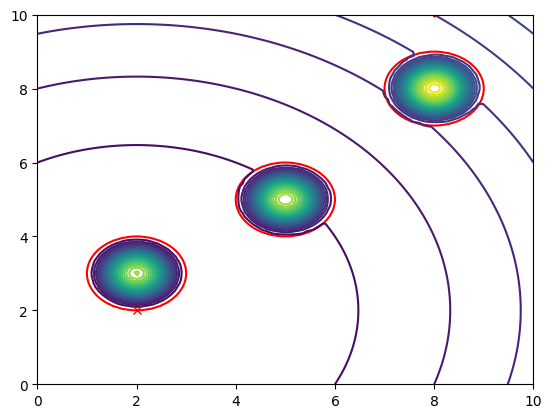

In [31]:
import matplotlib.pyplot as plt

# Test

h = 0.1
#h = 0.01
A = jnp.array( [[1, 0, h , 0], [0, 1, 0, h], [0, 0, 1, 0], [0, 0, 0, 1]] )
print(A)
B = jnp.array( [[0.5 * h * h, 0] , [0, 0.5 * h * h ], [h , 0], [0 , h] ] )
print(B)
n = 4 # number of states
m = 2 # number of controls
R = jnp.identity(2)
Tfinal = 5.0 # final time
mu_distr = 0


x_test =  jnp.array([[5.5], [5.5], [0], [0]])
iLQR_inst = iLQR(R, A, B, mu_distr, h, n, m, Tfinal, 8, 10)
print(iLQR_inst.constrains_error(x_test))

# Visualizing what is function L

iLQR_inst.set_target(jnp.array([2,2,0,0]).reshape(4,1))
iLQR_inst.visualize_field()

In [ ]:
# Rollout
xhist, uhist = iLQR_inst.rollout_i(1, False)
iLQR_inst.visualize_field()

========== REPORT ==========
Total cost:      2431.5715
State-control:   2342.0366
Obstacle cost:   89.5349
Equality cost:   0.0000
Penalty p:       1.0000
Backward pass in the area
H obstacle part eigenvalues: [2. 2. 2. 2.]
========== REPORT ==========
Total cost:      2431.5715
State-control:   2342.0366
Obstacle cost:   89.5349
Equality cost:   0.0000
Penalty p:       1.0000
Backward pass in the area
H obstacle part eigenvalues: [2. 2. 2. 2.]
========== REPORT ==========
Total cost:      2367.3215
State-control:   2313.4441
Obstacle cost:   53.8774
Equality cost:   0.0000
Penalty p:       1.0000
Backward pass in the area
H obstacle part eigenvalues: [2. 2. 2. 2.]
========== REPORT ==========
Total cost:      2364.6213
State-control:   2309.5891
Obstacle cost:   55.0323
Equality cost:   0.0000
Penalty p:       1.0000
Backward pass in the area
H obstacle part eigenvalues: [2. 2. 2. 2.]
========== REPORT ==========
Total cost:      2360.9197
State-control:   2304.2903
Obstacle cost:   

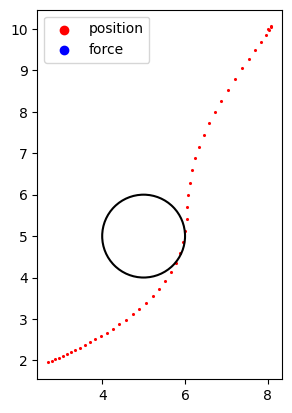

In [33]:
fig, ax = plt.subplots(1)
for k in range(0, xhist.shape[1] - 1):
    ax.scatter(xhist[0,k], xhist[1,k], color="red", s=1.5)
    #ax.quiver(xhist[0,k], xhist[1,k], uhist[0,k], uhist[1,k], color="blue", alpha=0.5)

circle = plt.Circle((5, 5), 1, color='black', fill=False, linewidth=1.5)
ax.add_patch(circle)
ax.set_aspect('equal')  # important — without this the circle will look like an ellipse

ax.scatter([], [], color="red", label="position")
ax.scatter([], [], color="blue", label="force")
ax.legend()


In [473]:
#x_test =  jnp.array([[5.5], [5.5], [0], [0]])
#iLQR_inst.constrains_error(x_test)
iLQR_inst.report()

========== REPORT ==========
Total cost:      5405.3422
State-control:   5405.3422
Obstacle cost:   0.0000
Equality cost:   0.0000
Penalty p:       1.2100


5405.3421789185295

[ 0.46217162 -0.35536297 -0.69385495 -0.51617952]


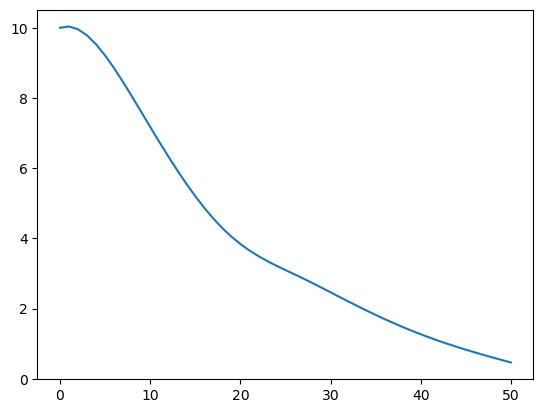

In [491]:
print(xhist[ :, -1])

distance_from_0 = jnp.sum(jnp.sqrt(xhist[0:1, : ]**2), axis=0)
plt.plot(distance_from_0)

[]


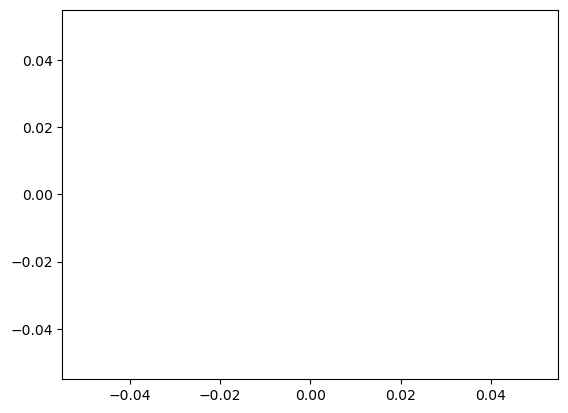

In [492]:
print(iLQR_inst.history)
plt.plot(iLQR_inst.history)